# HW2

## Exercise 1: Rejection Sampling

**目標分佈：**
$$f(x) = \frac{\pi}{2} \sin(\pi x), \quad x \in [0, 1]$$

**演算法步驟：**
1. 選擇容易採樣的候選分佈 $g(x)$，找常數 $M$ 使 $M \cdot g(x) \geq f(x)$ 對所有 $x$ 成立
2. 從 $g(x)$ 抽樣得 $x$
3. 從 $U(0,1)$ 抽樣得 $u$
4. 若 $u \leq \dfrac{f(x)}{M \cdot g(x)}$ 則接受，否則拒絕

**理論接受率：** $\dfrac{1}{M}$

---

### 兩種候選分佈比較

Candidate 2 的候選分佈為三角分佈：

$$g_2(x) = \begin{cases}4x & x\leq 0.5\\4(1-x) & x>0.5\end{cases}$$

| 候選 | $g(x)$ | $M$ | 理論接受率 |
|------|--------|-----|-----------|
| Candidate 1 | 均勻分佈 $U(0,1)$，$g(x)=1$ | $\pi/2 \approx 1.571$ | $2/\pi \approx 63.7\%$ |
| Candidate 2 | 三角分佈（見上式） | $\pi^2/8 \approx 1.234$ | $8/\pi^2 \approx 81.1\%$ |

  Candidate 1 (Uniform Envelope)
    理論 M₁ = 1.5708，理論接受率 = 0.6366
    實際接受率: 0.6277

  Candidate 2 (Triangular Envelope)
    理論 M₂ = 1.2337，理論接受率 = 0.8106
    實際接受率: 0.8065


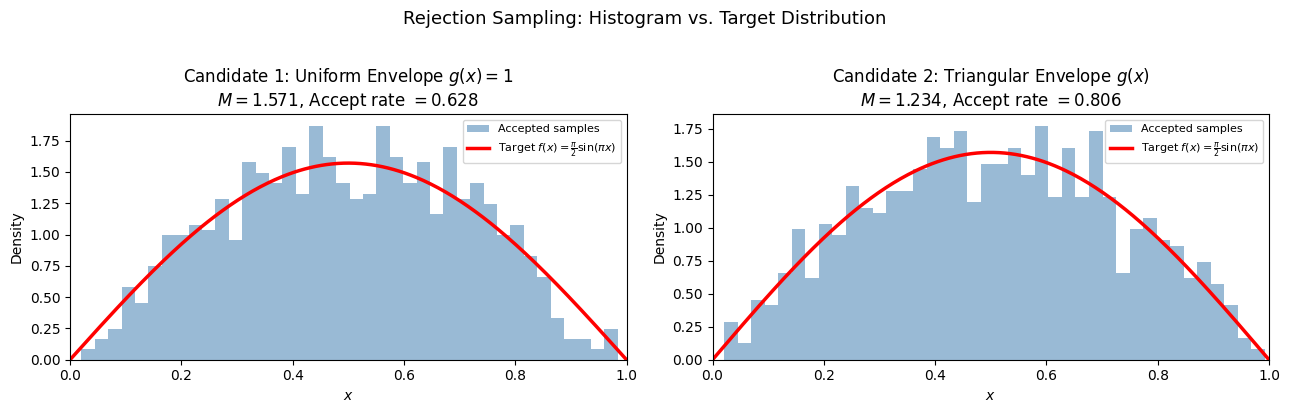

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 目標分布
def f(x):
    return (np.pi / 2) * np.sin(np.pi * x)


# 均勻分布
def sample_candidate1(n_samples):
    accepted = []
    total_trials = 0
    M1 = np.pi / 2

    while len(accepted) < n_samples:
        x = np.random.uniform(0, 1)   # 從 g1 抽樣
        u = np.random.uniform(0, 1)
        if u <= f(x) / M1:            # 接受條件（g1(x) = 1）
            accepted.append(x)
        total_trials += 1

    return np.array(accepted), n_samples / total_trials

# 三角分佈
def g2(x):
    return np.where(x <= 0.5, 4 * x, 4 * (1 - x))

def sample_candidate2(n_samples):
    accepted = []
    total_trials = 0
    M2 = np.pi**2 / 8

    while len(accepted) < n_samples:
        x = (np.random.uniform() + np.random.uniform()) / 2  # 從 g2 抽樣
        u = np.random.uniform(0, 1)
        g2_x = g2(x)
        if g2_x > 0 and u <= f(x) / (M2 * g2_x):  # 接受條件
            accepted.append(x)
        total_trials += 1

    return np.array(accepted), n_samples / total_trials


# ── 執行模擬 ──────────────────────────────────────────────────────────────────
N = 1000
s1, rate1 = sample_candidate1(N)
s2, rate2 = sample_candidate2(N)

print(f"  Candidate 1 (Uniform Envelope)")
print(f"    理論 M₁ = {np.pi/2:.4f}，理論接受率 = {2/np.pi:.4f}")
print(f"    實際接受率: {rate1:.4f}")
print()
print(f"  Candidate 2 (Triangular Envelope)")
print(f"    理論 M₂ = {np.pi**2/8:.4f}，理論接受率 = {8/np.pi**2:.4f}")
print(f"    實際接受率: {rate2:.4f}")

# ── 視覺化比較 ────────────────────────────────────────────────────────────────
x_vals = np.linspace(0.001, 0.999, 300)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle("Rejection Sampling: Histogram vs. Target Distribution", fontsize=13, y=1.02)

configs = [
    (s1, "Candidate 1: Uniform Envelope $g(x)=1$",       rate1, np.pi/2),
    (s2, "Candidate 2: Triangular Envelope $g(x)$",      rate2, np.pi**2/8),
]

for ax, (samples, title, rate, M) in zip(axes, configs):
    ax.hist(samples, bins=40, density=True, alpha=0.55, color="steelblue", label="Accepted samples")
    ax.plot(x_vals, f(x_vals), 'r-', lw=2.5, label=r"Target $f(x)=\frac{\pi}{2}\sin(\pi x)$")
    ax.set_title(f"{title}\n$M={M:.3f}$, Accept rate $= {rate:.3f}$")
    ax.set_xlabel("$x$")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Exercise 2a: Trapezoidal Rule

### 問題設定

計算 $\displaystyle\int_0^1 \frac{\sin x}{x}\,dx$（$x=0$ 處定義為 $1$），要求誤差 $< 0.001$。

**求最小 $n$：**

$$\frac{K}{12n^2} \leq 0.001 \implies n \geq \sqrt{\frac{K}{0.012}}$$

**步驟：**
1. 用數值二階差分估計 $K = \max |f''(x)|$：$\quad f''(x) \approx \dfrac{f(x+h) - 2f(x) + f(x-h)}{h^2}$
2. 代入公式求最小 $n$
3. 用梯形法計算積分，與精確值比較驗證

In [9]:
import numpy as np
import math
from scipy import integrate

# 被積函數
def f(x):
    return np.where(np.abs(x) < 1e-10, 1.0, np.sin(x) / x)

# 數值二階導數
def f_double_prime(x, h=1e-5):
    return (f(x + h) - 2 * f(x) + f(x - h)) / h**2

# 估計 K = max|f''(x)| on [0, 1] 
x_vals = np.linspace(1e-6, 1)          # 在積分區間 [0,1] 取樣（避開 x=0 數值問題）
K = np.max(np.abs(f_double_prime(x_vals)))
print(f"K = max|f''(x)| ≈ {K:.6f}")

# 由誤差界求最小 n 
# 誤差界：K / (12 n²) ≤ 0.001  →  n ≥ √(K / 0.012)
n_min = math.ceil(math.sqrt(K / 0.012))
print(f"需要 n ≥ {n_min}")

# 套用梯形法計算積分 
n = n_min
x = np.linspace(0, 1, n + 1)          # n+1 個節點：x₀, x₁, ..., xₙ
y = f(x)
h = 1 / n

trap = h * (y[0] / 2 + np.sum(y[1:-1]) + y[-1] / 2)

#  與精確值比較 
exact, _ = integrate.quad(f, 0, 1)
error = abs(trap - exact)

print()
print(f"梯形法結果 (n={n}): {trap:.8f}")
print(f"精確值:             {exact:.8f}")
print(f"實際誤差:           {error:.8f}  ({'✓ < 0.001' if error < 0.001 else '✗ ≥ 0.001'})")

K = max|f''(x)| ≈ 0.333334
需要 n ≥ 6

梯形法結果 (n=6): 0.94538573
精確值:             0.94608307
實際誤差:           0.00069734  (✓ < 0.001)


/var/folders/gv/755jwkvj1_7gncxqw4flsmch0000gn/T/ipykernel_15582/827295122.py:7: RuntimeWarning: invalid value encountered in divide
  return np.where(np.abs(x) < 1e-10, 1.0, np.sin(x) / x)


## Exercise 2b: Simpson's Rule

### 理論背景

**Simpson's Rule** 用拋物線段近似被積函數，精度高於梯形法（誤差為 $O(h^4)$）：

$$\int_a^b f(x)\,dx \approx \frac{h}{3}\bigl[f(x_0) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \cdots + 4f(x_{n-1}) + f(x_n)\bigr]$$

其中 $h = (b-a)/n$，$n$ 必須為**偶數**，係數規律為 $1,\,4,\,2,\,4,\,2,\,\ldots,\,4,\,1$。

---

### 問題設定

估計一個橫截面為半圓形的游泳池體積：

- 池長 $16$ ft，每隔 $2$ ft 量測直徑，共 9 個截面
- 量測直徑（ft）：$0,\ 10,\ 12,\ 10,\ 8,\ 6,\ 8,\ 10,\ 0$
- 各截面積（半圓）：$A(x) = \dfrac{\pi d^2}{8}$
- 對截面積沿長度積分得體積：$V = \displaystyle\int_0^{16} A(x)\,dx \approx \frac{h}{3}\sum_i c_i A_i$

In [10]:
import numpy as np

# 量測資料 
diameters = np.array([0, 10, 12, 10, 8, 6, 8, 10, 0], dtype=float)  # ft
x_pos = np.arange(0, 17, 2)   # 截面位置：0, 2, 4, ..., 16 ft
h = 2                          # 截面間距 2 ft
n = len(diameters) - 1

# 各截面積（半圓）
# 半圓截面積 A = π(d/2)²/2 = πd²/8
A = np.pi * diameters**2 / 8

print("各截面積 A(x):")
print(f"{'位置':>6}  {'直徑 d':>8}  {'截面積 A':>12}")
print("-" * 32)
for xi, di, ai in zip(x_pos, diameters, A):
    print(f"{xi:4d} ft  {di:5.0f} ft  {ai:10.4f} ft²")

#  Simpson's Rule 係數 
# 係數規律：1, 4, 2, 4, 2, ..., 4, 1
coeffs = np.ones(n + 1)
coeffs[1:-1:2] = 4   # 奇數索引
coeffs[2:-2:2] = 2   # 偶數索引（中間）

print(f"\nSimpson 係數：{coeffs.astype(int).tolist()}")

# 計算體積
V = (h / 3) * np.dot(coeffs, A)

print(f"\n游泳池體積 (Simpson's Rule):")
print(f"  V ≈ {V:.4f} ft³")
print(f"  V ≈ {V:.2f} ft³")

各截面積 A(x):
    位置      直徑 d         截面積 A
--------------------------------
   0 ft      0 ft      0.0000 ft²
   2 ft     10 ft     39.2699 ft²
   4 ft     12 ft     56.5487 ft²
   6 ft     10 ft     39.2699 ft²
   8 ft      8 ft     25.1327 ft²
  10 ft      6 ft     14.1372 ft²
  12 ft      8 ft     25.1327 ft²
  14 ft     10 ft     39.2699 ft²
  16 ft      0 ft      0.0000 ft²

Simpson 係數：[1, 4, 2, 4, 2, 4, 2, 4, 1]

游泳池體積 (Simpson's Rule):
  V ≈ 494.2772 ft³
  V ≈ 494.28 ft³
